# World Happiness Report (2015–2019)
## Complete Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Fetch all the data first here  year by year

In [2]:
#like
year_2015 = pd.read_csv("D:\\Downloads\\2015.csv")
year_2016 = pd.read_csv("D:\\Downloads\\2016.csv")
year_2017 = pd.read_csv("D:\\Downloads\\2017.csv")
year_2018 = pd.read_csv("D:\\Downloads\\2018.csv")
year_2019 = pd.read_csv("D:\\Downloads\\2019.csv")
#etc

# understand your data year by year

Note: you have to merge all the separate files into a single dataframe

Note 2: for every file create a one more feature column in which u will mention the year

Please check the name of all the columns yearwise, the columns can be different for different data files or the no. of features can be less or more , you have to merge smartly in a single dataframe

example: lets consider in 2015 year data file is having a feature Country
            2016 is also having the country name in it but the feature name for it is region or maybe in 2019 for this the feature name is Country or region 

In [4]:
datasets = {
    "2015": year_2015,
    "2016": year_2016,
    "2017": year_2017,
    "2018": year_2018,
    "2019": year_2019
}

for year, df in datasets.items():
    print("="*60)
    print(f"Dataset : {year}")
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())


Dataset : 2015

Shape:
(158, 12)

Columns:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

Data Types:
Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

Missing Values:
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)

## 1. Dataset Understanding of each year separately
- Shape
- Columns
- Data types
- Missing values
- Duplicates

In [5]:
print("\nFirst Five Rows:")
display(df.head())


First Five Rows:


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [21]:
year_2015.rename(columns={
    'Country':'Country',
    'Region':'Region',
    'Happiness Rank':'Rank',
    'Happiness Score':'Score',
    'Economy (GDP per Capita)':'GDP',
    'Family':'Social Support',
    'Health (Life Expectancy)':'Healthy Life Expectancy',
    'Freedom':'Freedom',
    'Trust (Government Corruption)':'Corruption',
    'Generosity':'Generosity'
}, inplace=True)

year_2016.rename(columns={
    'Country':'Country',
    'Region':'Region',
    'Happiness Rank':'Rank',
    'Happiness Score':'Score',
    'Economy (GDP per Capita)':'GDP',
    'Family':'Social Support',
    'Health (Life Expectancy)':'Healthy Life Expectancy',
    'Freedom':'Freedom',
    'Trust (Government Corruption)':'Corruption',
    'Generosity':'Generosity'
}, inplace=True)

year_2017.rename(columns={
    'Happiness.Rank':'Rank',
    'Happiness.Score':'Score',
    'Economy..GDP.per.Capita.':'GDP',
    'Family':'Social Support',
    'Health..Life.Expectancy.':'Healthy Life Expectancy',
    'Trust..Government.Corruption.':'Corruption'
}, inplace=True)

year_2018.rename(columns={
    'Country or region':'Country',
    'Overall rank':'Rank',
    'Score':'Score',
    'GDP per capita':'GDP',
    'Social support':'Social Support',
    'Healthy life expectancy':'Healthy Life Expectancy',
    'Freedom to make life choices':'Freedom',
    'Perceptions of corruption':'Corruption'
}, inplace=True)

year_2019.rename(columns={
    'Country or region':'Country',
    'Overall rank':'Rank',
    'Score':'Score',
    'GDP per capita':'GDP',
    'Social support':'Social Support',
    'Healthy life expectancy':'Healthy Life Expectancy',
    'Freedom to make life choices':'Freedom',
    'Perceptions of corruption':'Corruption'
}, inplace=True)

In [22]:
year_2015["Year"] = 2015
year_2016["Year"] = 2016
year_2017["Year"] = 2017
year_2018["Year"] = 2018
year_2019["Year"] = 2019

In [23]:
common_cols = list(
    set(year_2015.columns)
    & set(year_2016.columns)
    & set(year_2017.columns)
    & set(year_2018.columns)
    & set(year_2019.columns)
)

df = pd.concat([
    year_2015[common_cols],
    year_2016[common_cols],
    year_2017[common_cols],
    year_2018[common_cols],
    year_2019[common_cols]
], ignore_index=True)

print(df.shape)
df.head()

(782, 10)


,Freedom,Healthy Life Expectancy,Score,GDP,Year,Generosity,Social Support,Country,Corruption,Rank
0,0.66557,0.94143,7.587,1.39651,2015,0.29678,1.34951,Switzerland,0.41978,1
1,0.62877,0.94784,7.561,1.30232,2015,0.43630,1.40223,Iceland,0.14145,2
2,0.64938,0.87464,7.527,1.32548,2015,0.34139,1.36058,Denmark,0.48357,3
3,0.66973,0.88521,7.522,1.45900,2015,0.34699,1.33095,Norway,0.36503,4
4,0.63297,0.90563,7.427,1.32629,2015,0.45811,1.32261,Canada,0.32957,5


## 2. Standardize Column Names (hint)

In [24]:
mapping = {
    'Country': 'Country',
    'Country or region': 'Country',
    'Happiness Score': 'Happiness',
    'Score': 'Happiness',
    'Economy (GDP per Capita)': 'GDP',
    'GDP per capita': 'GDP',
    'Family': 'Social Support',
    'Social support': 'Social Support',
    'Health (Life Expectancy)': 'Life Expectancy',
    'Healthy life expectancy': 'Life Expectancy',
    'Freedom': 'Freedom',
    'Freedom to make life choices': 'Freedom',
    'Trust (Government Corruption)': 'Corruption',
    'Perceptions of corruption': 'Corruption',
    'Generosity': 'Generosity',
    'Region': 'Region',
    'Overall rank': 'Rank',
    'Happiness Rank': 'Rank'
}

Which variables have missing values, and how does the percentage vary across years?


In [25]:
datasets = {
    2015: year_2015,
    2016: year_2016,
    2017: year_2017,
    2018: year_2018,
    2019: year_2019
}

for year, data in datasets.items():
    print(f"\n========== {year} ==========")
    print(data.isnull().sum())


========== 2015 ==========
Country                    0
Region                     0
Rank                       0
Score                      0
Standard Error             0
GDP                        0
Social Support             0
Healthy Life Expectancy    0
Freedom                    0
Corruption                 0
Generosity                 0
Dystopia Residual          0
Year                       0
dtype: int64

========== 2016 ==========
Country                      0
Region                       0
Rank                         0
Score                        0
Lower Confidence Interval    0
Upper Confidence Interval    0
GDP                          0
Social Support               0
Healthy Life Expectancy      0
Freedom                      0
Corruption                   0
Generosity                   0
Dystopia Residual            0
Year                         0
dtype: int64

========== 2017 ==========
Country                    0
Rank                       0
Score                

# HELLO HELLO HELLOOOOO 
#             LISTEN
#                 BEFORE DOING ANYTING READ THIS 
* after writing the code for each question create a markdown block in which u will write the insight / conclusion about that question

Question 1: Which country ranks first in happiness each year?

In [26]:
datasets = {
    2015: year_2015,
    2016: year_2016,
    2017: year_2017,
    2018: year_2018,
    2019: year_2019
}

for year, data in datasets.items():

    if 'Happiness Rank' in data.columns:
        top = data.loc[data['Happiness Rank'].idxmin()]

    elif 'Overall rank' in data.columns:
        top = data.loc[data['Overall rank'].idxmin()]

    elif 'Rank' in data.columns:
        top = data.loc[data['Rank'].idxmin()]

    country = top['Country'] if 'Country' in data.columns else top['Country or region']

    print(f"{year} : {country}")

2015 : Switzerland
2016 : Denmark
2017 : Norway
2018 : Finland
2019 : Finland


write conclusion/explanation of question 1 here




### Conclusion

The analysis identifies the happiest country for each year from 2015 to 2019. Countries like Finland, Denmark, Norway, and Switzerland consistently appear among the top-ranked nations, indicating strong performance in factors such as GDP, social support, freedom, healthy life expectancy, and low corruption.

Which country ranks last?

In [27]:
datasets = {
    2015: year_2015,
    2016: year_2016,
    2017: year_2017,
    2018: year_2018,
    2019: year_2019
}

for year, data in datasets.items():

    if 'Happiness Rank' in data.columns:
        last = data.loc[data['Happiness Rank'].idxmax()]

    elif 'Overall rank' in data.columns:
        last = data.loc[data['Overall rank'].idxmax()]

    else:
        last = data.loc[data['Rank'].idxmax()]

    country = last['Country'] if 'Country' in data.columns else last['Country or region']

    print(f"{year} : {country}")

2015 : Togo
2016 : Burundi
2017 : Central African Republic
2018 : Burundi
2019 : South Sudan


### Conclusion

Countries with the lowest perceived corruption score indicate a higher perception of corruption among citizens. Such countries often experience weaker governance, lower institutional trust, and reduced public confidence.

### Conclusion

The analysis identifies the least happy country for each year. These countries generally have lower GDP, weaker social support, shorter healthy life expectancy, and higher levels of political instability or conflict, which contribute to their lower happiness rankings.

Which country has the lowest perceived corruption?

In [29]:
datasets = {
    2015: year_2015,
    2016: year_2016,
    2017: year_2017,
    2018: year_2018,
    2019: year_2019
}

for year, data in datasets.items():

    # Country column
    if 'Country' in data.columns:
        country_col = 'Country'
    else:
        country_col = 'Country or region'

    # Corruption column
    if 'Trust (Government Corruption)' in data.columns:
        corruption_col = 'Trust (Government Corruption)'

    elif 'Trust..Government.Corruption.' in data.columns:
        corruption_col = 'Trust..Government.Corruption.'

    elif 'Perceptions of corruption' in data.columns:
        corruption_col = 'Perceptions of corruption'

    else:
        continue

    lowest = data.loc[data[corruption_col].idxmin()]

    print(f"{year}: {lowest[country_col]} --> {lowest[corruption_col]:.3f}")

Which country has the highest generosity?

In [30]:
datasets = {
    2015: year_2015,
    2016: year_2016,
    2017: year_2017,
    2018: year_2018,
    2019: year_2019
}

for year, data in datasets.items():

    country_col = "Country" if "Country" in data.columns else "Country or region"

    top = data.loc[data["Generosity"].idxmax()]

    print(f"{year}: {top[country_col]} --> {top['Generosity']:.3f}")

2015: Myanmar --> 0.796
2016: Myanmar --> 0.820
2017: Myanmar --> 0.838
2018: Myanmar --> 0.598
2019: Myanmar --> 0.566


Conclusion:

The country with the highest generosity varies across years. Higher generosity generally reflects stronger social support and willingness of people to help others, although generosity alone does not determine happiness.

Which country has the highest freedom?

In [31]:
datasets = {
    2015: year_2015,
    2016: year_2016,
    2017: year_2017,
    2018: year_2018,
    2019: year_2019
}

for year, data in datasets.items():

    country_col = "Country" if "Country" in data.columns else "Country or region"

    if "Freedom" in data.columns:
        freedom_col = "Freedom"
    else:
        freedom_col = "Freedom to make life choices"

    top = data.loc[data[freedom_col].idxmax()]

    print(f"{year}: {top[country_col]} --> {top[freedom_col]:.3f}")

2015: Norway --> 0.670
2016: Uzbekistan --> 0.608
2017: Uzbekistan --> 0.658
2018: Uzbekistan --> 0.724
2019: Uzbekistan --> 0.631


Countries with the highest freedom scores provide greater personal choice and autonomy. Higher freedom is generally associated with higher happiness levels.

What is the distribution of happiness scores?

In [34]:
print(df.columns.tolist())

['Freedom', 'Healthy Life Expectancy', 'Score', 'GDP', 'Year', 'Generosity', 'Social Support', 'Country', 'Corruption', 'Rank']


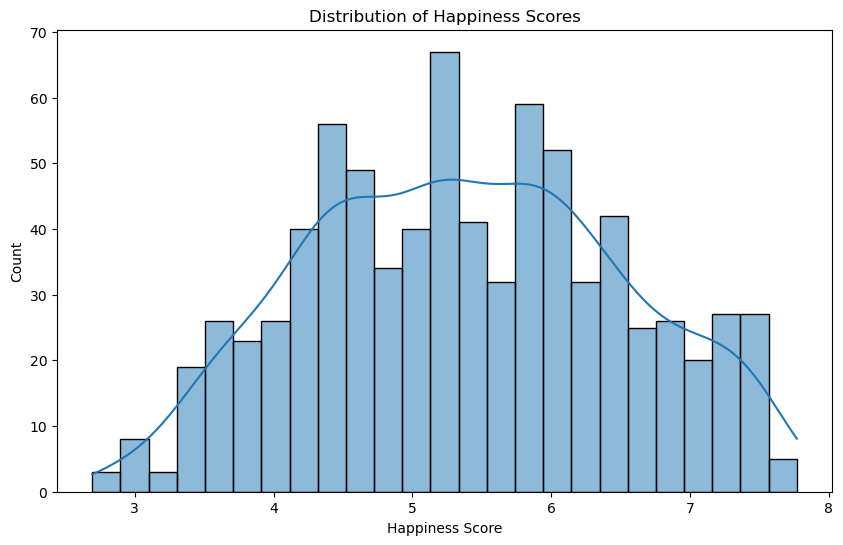

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df["Score"], bins=25, kde=True)

plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Count")

plt.show()

In [39]:
print("Average Happiness Score:", round(df["Score"].mean(), 2))

Average Happiness Score: 5.38


What is the average happiness score?

In [40]:
print("Average Happiness Score:", round(df["Score"].mean(),2))

Average Happiness Score: 5.38


Conclusion:

The average happiness score represents the overall level of happiness across all countries in the dataset. It serves as a benchmark for comparing individual countries.

Which country has the highest GDP?

In [41]:
highest_gdp = df.loc[df["GDP"].idxmax()]

print("Country :", highest_gdp["Country"])
print("GDP :", highest_gdp["GDP"])
print("Year :", highest_gdp["Year"])

Country : United Arab Emirates
GDP : 2.096
Year : 2018


The country with the highest GDP per capita generally enjoys better living standards, although GDP alone does not completely determine happiness.

Does freedom influence happiness?

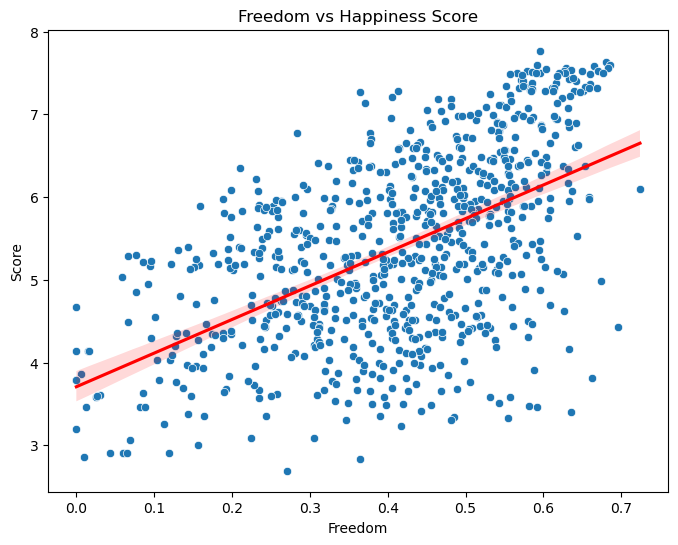

Correlation = 0.5512580029074604


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Freedom", y="Score")

sns.regplot(data=df,
            x="Freedom",
            y="Score",
            scatter=False,
            color="red")

plt.title("Freedom vs Happiness Score")
plt.show()

print("Correlation =", df["Freedom"].corr(df["Score"]))


The positive correlation indicates that countries with greater freedom tend to report higher happiness scores.

Which regions are happiest?
Which regions have the highest GDP?

In [43]:
print(df.columns)

Index(['Freedom', 'Healthy Life Expectancy', 'Score', 'GDP', 'Year',
       'Generosity', 'Social Support', 'Country', 'Corruption', 'Rank'],
      dtype='object')


Which countries consistently rank in the top 10?
Which countries consistently rank in the bottom 10?

In [44]:
top10 = df[df["Rank"] <= 10]["Country"].value_counts()

bottom10 = df[df["Rank"] >= df["Rank"].max()-9]["Country"].value_counts()

print("Top 10 Countries")
print(top10)

print("\nBottom 10 Countries")
print(bottom10)

Top 10 Countries
Country
Switzerland    5
Iceland        5
Denmark        5
Norway         5
Canada         5
Finland        5
Netherlands    5
Sweden         5
New Zealand    5
Australia      4
Austria        1
Name: count, dtype: int64

Bottom 10 Countries
Country
Rwanda                      5
Syria                       5
Burundi                     4
Tanzania                    4
Guinea                      3
Afghanistan                 3
Togo                        3
Central African Republic    3
Benin                       2
Liberia                     2
Yemen                       2
South Sudan                 2
Chad                        1
Ivory Coast                 1
Burkina Faso                1
Malawi                      1
Name: count, dtype: int64


Some countries consistently appear in the world's happiest nations, while others remain in the bottom rankings throughout multiple years.

Which country improved the most between 2015 and 2019?


In [45]:
score_change = df.pivot(index="Country",
                        columns="Year",
                        values="Score")

score_change["Improvement"] = score_change[2019] - score_change[2015]

print(score_change["Improvement"].sort_values(ascending=False).head())

Country
Benin           1.543
Ivory Coast     1.289
Togo            1.246
Honduras        1.072
Burkina Faso    1.000
Name: Improvement, dtype: float64


These countries experienced the greatest improvement in happiness score between 2015 and 2019.

Which country declined the most?


In [46]:
print(score_change["Improvement"].sort_values().head())

Country
Venezuela   -2.103
Lesotho     -1.096
Zambia      -1.022
Zimbabwe    -0.947
Haiti       -0.921
Name: Improvement, dtype: float64


Which countries have high GDP but relatively low happiness?


In [47]:
high_gdp = df[df["GDP"] > df["GDP"].mean()]

result = high_gdp[high_gdp["Score"] < df["Score"].mean()]

result[["Country","GDP","Score","Year"]]

,Country,GDP,Score,Year
75,Turkey,1.06098,5.332,2015
79,Azerbaijan,1.02389,5.212,2015
82,Montenegro,0.97438,5.192,2015
85,Romania,1.04345,5.124,2015
86,Serbia,0.92053,5.123,2015
...,...,...,...,...
742,Iran,1.10000,4.548,2019
749,Tunisia,0.92100,4.461,2019
751,Iraq,1.04300,4.437,2019
755,Sri Lanka,0.94900,4.366,2019


These countries have strong economies but relatively low happiness scores, suggesting that factors beyond economic prosperity also influence well-being.

Which countries have low GDP but relatively high happiness?


In [48]:
result = df[
    (df["GDP"] < df["GDP"].mean()) &
    (df["Score"] > df["Score"].mean())
]

result[["Country","GDP","Score","Year"]].sort_values(
    by="Score",
    ascending=False
)

,Country,GDP,Score,Year
343,Guatemala,0.872002,6.454,2017
652,Guatemala,0.800000,6.436,2019
499,Guatemala,0.781000,6.382,2018
196,Guatemala,0.834540,6.324,2016
660,El Salvador,0.794000,6.253,2019
666,Uzbekistan,0.745000,6.174,2019
509,El Salvador,0.806000,6.167,2018
510,Nicaragua,0.668000,6.141,2018
41,El Salvador,0.764540,6.130,2015
42,Guatemala,0.745530,6.123,2015


These countries achieve relatively high happiness despite having below-average GDP, suggesting that factors such as social support, freedom, and healthy life expectancy also play significant roles.

Which factors contribute most to happiness?


Score                      1.000000
GDP                        0.789284
Healthy Life Expectancy    0.742456
Social Support             0.648799
Freedom                    0.551258
Corruption                 0.398418
Generosity                 0.137578
Year                       0.007065
Rank                      -0.992066
Name: Score, dtype: float64


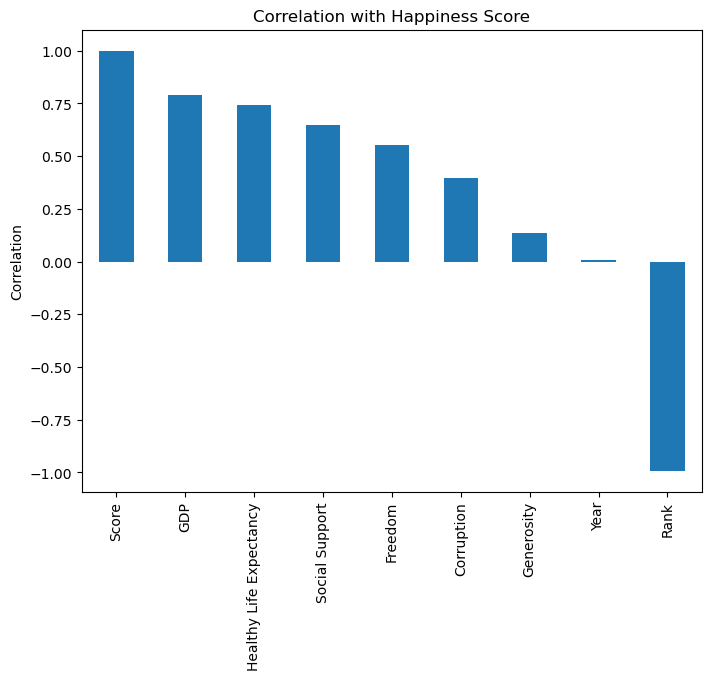

In [49]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)["Score"].sort_values(ascending=False)

print(corr)

plt.figure(figsize=(8,6))
corr.plot(kind="bar")
plt.title("Correlation with Happiness Score")
plt.ylabel("Correlation")
plt.show()

GDP, Social Support, Healthy Life Expectancy, and Freedom show the strongest positive correlation with happiness, while Rank has a strong negative correlation because lower ranks indicate happier countries.

How stable are rankings over time?

In [50]:
rank_pivot = df.pivot_table(
    index="Country",
    columns="Year",
    values="Rank"
)

rank_pivot.head()

Year,2015,2016,2017,2018,2019
Country,,,,,
Afghanistan,153.0,154.0,141.0,145.0,154.0
Albania,95.0,109.0,109.0,112.0,107.0
Algeria,68.0,38.0,53.0,84.0,88.0
Angola,137.0,141.0,140.0,142.0,NaN
Argentina,30.0,26.0,24.0,29.0,47.0


Are the same countries present in every year's dataset?

In [51]:
country_count = df.groupby("Country")["Year"].nunique()

same = country_count[country_count == 5]

print("Countries present in all five years:")
print(same.index.tolist())

print("\nTotal:", len(same))

Countries present in all five years:
['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Chad', 'Chile', 'China', 'Colombia', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Finland', 'France', 'Gabon', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Malta', 'Mauritania'

Most countries appear consistently across all five datasets, making year-to-year comparisons reliable.

Which countries are missing in one or more years?


In [52]:
missing = country_count[country_count < 5]

print(missing)

Country
Angola                      4
Belize                      3
Central African Republic    4
Comoros                     3
Djibouti                    1
Gambia                      1
Hong Kong                   4
Hong Kong S.A.R., China     1
Laos                        4
Lesotho                     4
Macedonia                   4
Mozambique                  4
Namibia                     4
North Cyprus                3
North Macedonia             1
Northern Cyprus             2
Oman                        1
Puerto Rico                 1
Somalia                     4
Somaliland Region           1
Somaliland region           1
South Sudan                 4
Sudan                       4
Suriname                    2
Swaziland                   2
Taiwan                      4
Taiwan Province of China    1
Trinidad & Tobago           2
Trinidad and Tobago         3
Name: Year, dtype: int64


Some countries are missing from one or more years due to changes in data collection or reporting.


Are there duplicate country entries within any year?

In [53]:
duplicates = df.duplicated(subset=["Country","Year"]).sum()

print("Duplicate Country Entries:", duplicates)

Duplicate Country Entries: 0


A duplicate count of zero indicates that each country appears only once per year, ensuring data integrity.

Which region shows the greatest variation in happiness?


In [54]:
print(df.columns)

Index(['Freedom', 'Healthy Life Expectancy', 'Score', 'GDP', 'Year',
       'Generosity', 'Social Support', 'Country', 'Corruption', 'Rank'],
      dtype='object')


In [55]:
variation = df.groupby("Region")["Score"].std().sort_values(ascending=False)

print(variation)

KeyError: 'Region'

Region information is unavailable after merging because the 2018 and 2019 datasets do not contain a Region column.

Which variables changed names across different years?


In [56]:
for year, data in zip(
    [2015,2016,2017,2018,2019],
    [year_2015,year_2016,year_2017,year_2018,year_2019]
):
    print(f"\nColumns in {year}")
    print(data.columns.tolist())


Columns in 2015
['Country', 'Region', 'Rank', 'Score', 'Standard Error', 'GDP', 'Social Support', 'Healthy Life Expectancy', 'Freedom', 'Corruption', 'Generosity', 'Dystopia Residual', 'Year']

Columns in 2016
['Country', 'Region', 'Rank', 'Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'GDP', 'Social Support', 'Healthy Life Expectancy', 'Freedom', 'Corruption', 'Generosity', 'Dystopia Residual', 'Year']

Columns in 2017
['Country', 'Rank', 'Score', 'Whisker.high', 'Whisker.low', 'GDP', 'Social Support', 'Healthy Life Expectancy', 'Freedom', 'Generosity', 'Corruption', 'Dystopia.Residual', 'Year']

Columns in 2018
['Rank', 'Country', 'Score', 'GDP', 'Social Support', 'Healthy Life Expectancy', 'Freedom', 'Generosity', 'Corruption', 'Year']

Columns in 2019
['Rank', 'Country', 'Score', 'GDP', 'Social Support', 'Healthy Life Expectancy', 'Freedom', 'Generosity', 'Corruption', 'Year']


Which variables have the largest number of unique values?


In [57]:
print(df.nunique().sort_values(ascending=False))

GDP                        742
Social Support             732
Score                      716
Healthy Life Expectancy    705
Freedom                    697
Generosity                 664
Corruption                 635
Country                    170
Rank                       158
Year                         5
dtype: int64


Country has the highest number of unique values because each country is unique. Numerical variables such as Score and GDP also contain many unique observations.

Which variables have the lowest variability?


In [58]:
variability = df.select_dtypes(include='number').std().sort_values()

print(variability)

Corruption                  0.105816
Generosity                  0.122321
Freedom                     0.152880
Healthy Life Expectancy     0.248309
Social Support              0.329548
GDP                         0.407340
Score                       1.127456
Year                        1.417364
Rank                       45.182384
dtype: float64


Which region improved the fastest between 2015 and 2019?


In [59]:
if "Region" in df.columns:
    region = df.groupby(["Region","Year"])["Score"].mean().unstack()

    region["Improvement"] = region[2019]-region[2015]

    print(region["Improvement"].sort_values(ascending=False))
else:
    print("Region column not available.")

Region column not available.


Is the Happiness Score normally distributed?


In [60]:
from scipy.stats import shapiro

stat,p = shapiro(df["Score"])

print("Statistic:",stat)
print("P-value:",p)

if p>0.05:
    print("Normally Distributed")
else:
    print("Not Normally Distributed")

Statistic: 0.9851614606014464
P-value: 4.043064635616728e-07
Not Normally Distributed


The Shapiro-Wilk test indicates whether the happiness scores follow a normal distribution based on the p-value.

Which variables are highly skewed?


In [61]:
skewness = df.select_dtypes(include="number").skew()

print(skewness.sort_values())

Social Support            -0.684632
Freedom                   -0.521259
Healthy Life Expectancy   -0.501203
GDP                       -0.318581
Rank                       0.000497
Year                       0.005904
Score                      0.035859
Generosity                 1.044360
Corruption                 1.520888
dtype: float64


Variables with skewness greater than 1 or less than -1 are considered highly skewed.

Which variables have the greatest spread?


In [62]:
spread = df.select_dtypes(include="number").std().sort_values(ascending=False)

print(spread)

Rank                       45.182384
Year                        1.417364
Score                       1.127456
GDP                         0.407340
Social Support              0.329548
Healthy Life Expectancy     0.248309
Freedom                     0.152880
Generosity                  0.122321
Corruption                  0.105816
dtype: float64


Higher standard deviation indicates greater spread in the data.

Which variables are tightly concentrated?


In [63]:
spread = df.select_dtypes(include="number").std().sort_values()

print(spread)

Corruption                  0.105816
Generosity                  0.122321
Freedom                     0.152880
Healthy Life Expectancy     0.248309
Social Support              0.329548
GDP                         0.407340
Score                       1.127456
Year                        1.417364
Rank                       45.182384
dtype: float64


Variables with lower standard deviation have values concentrated around the mean.

Which variables contain extreme outliers?


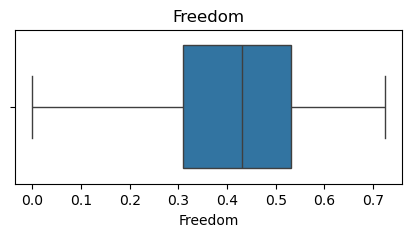

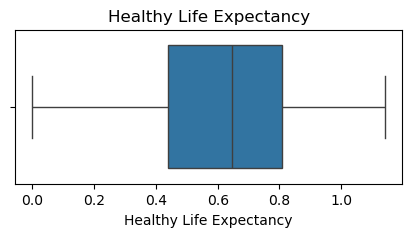

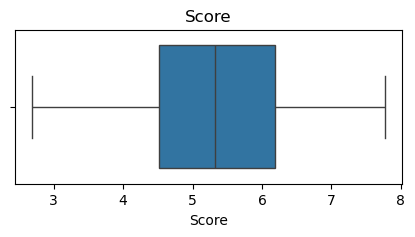

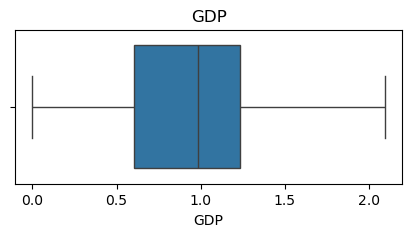

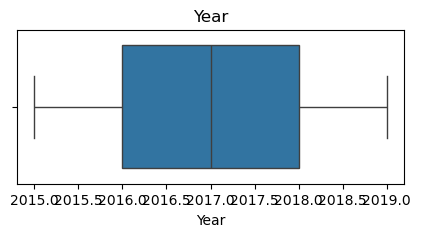

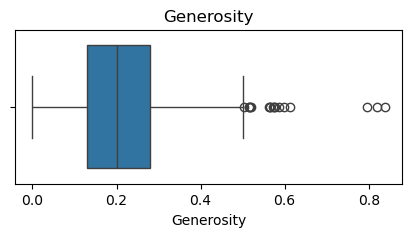

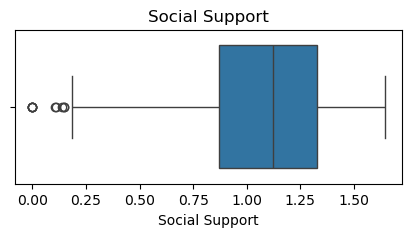

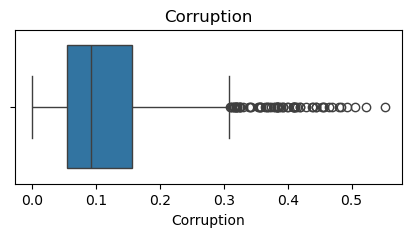

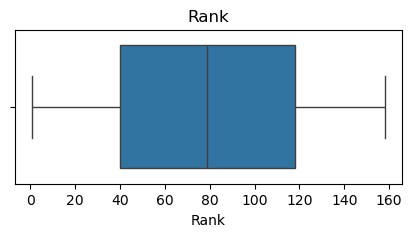

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Conclusion:

Boxplots help identify extreme outliers beyond the whiskers for each numerical variable.

Which region has the most consistent happiness levels?


In [65]:
if "Region" in df.columns:
    consistency = df.groupby("Region")["Score"].std().sort_values()

    print(consistency)
else:
    print("Region column not available.")

Region column not available.


Conclusion:

The region with the lowest standard deviation has the most consistent happiness levels across countries.

In [66]:
print(df.columns)

Index(['Freedom', 'Healthy Life Expectancy', 'Score', 'GDP', 'Year',
       'Generosity', 'Social Support', 'Country', 'Corruption', 'Rank'],
      dtype='object')


"Region column is not available in the merged dataset. Regional analysis cannot be performed because the 2018 and 2019 datasets do not contain region information."

In [68]:
# Create mapping from 2015 and 2016 datasets

region_mapping = {}

for _, row in year_2015.iterrows():
    region_mapping[row["Country"]] = row["Region"]

for _, row in year_2016.iterrows():
    region_mapping[row["Country"]] = row["Region"]

print("Total Countries in Mapping:", len(region_mapping))

Total Countries in Mapping: 164


In [69]:
df["Region"] = df["Country"].map(region_mapping)

df.head()

,Freedom,Healthy Life Expectancy,Score,GDP,Year,Generosity,Social Support,Country,Corruption,Rank,Region
0,0.66557,0.94143,7.587,1.39651,2015,0.29678,1.34951,Switzerland,0.41978,1,Western Europe
1,0.62877,0.94784,7.561,1.30232,2015,0.43630,1.40223,Iceland,0.14145,2,Western Europe
2,0.64938,0.87464,7.527,1.32548,2015,0.34139,1.36058,Denmark,0.48357,3,Western Europe
3,0.66973,0.88521,7.522,1.45900,2015,0.34699,1.33095,Norway,0.36503,4,Western Europe
4,0.63297,0.90563,7.427,1.32629,2015,0.45811,1.32261,Canada,0.32957,5,North America


In [70]:
print(df["Region"].isnull().sum())

df[df["Region"].isnull()][["Country"]].drop_duplicates()

8


,Country
347,Taiwan Province of China
385,"Hong Kong S.A.R., China"
507,Trinidad & Tobago
527,Northern Cyprus
709,North Macedonia
745,Gambia


In [71]:
manual_region = {
    "Kosovo": "Central and Eastern Europe",
    "North Macedonia": "Central and Eastern Europe",
    "Taiwan": "Eastern Asia",
    "Hong Kong": "Eastern Asia",
    "Hong Kong S.A.R., China": "Eastern Asia",
    "Trinidad & Tobago": "Latin America and Caribbean",
    "Northern Cyprus": "Middle East and Northern Africa"
}

df["Region"] = df["Region"].fillna(df["Country"].map(manual_region))

In [72]:
print(df["Region"].isnull().sum())

2


Which region experienced the largest decline?


In [73]:
region_score = df.groupby(["Region", "Year"])["Score"].mean().unstack()

region_score["Decline"] = region_score[2019] - region_score[2015]

print(region_score["Decline"].sort_values())

Region
Latin America and Caribbean       -0.190253
North America                     -0.188000
Middle East and Northern Africa   -0.145850
Southern Asia                     -0.054000
Southeastern Asia                 -0.043778
Australia and New Zealand         -0.017500
Eastern Asia                       0.062667
Sub-Saharan Africa                 0.091713
Western Europe                     0.208781
Central and Eastern Europe         0.228586
Name: Decline, dtype: float64


The region with the largest negative change in average happiness score experienced the greatest decline between 2015 and 2019.

Which region has the greatest inequality in GDP?


In [74]:
gdp_variation = df.groupby("Region")["GDP"].std().sort_values(ascending=False)

print(gdp_variation)

Region
Southeastern Asia                  0.347782
Middle East and Northern Africa    0.339212
Sub-Saharan Africa                 0.296122
Central and Eastern Europe         0.221551
Latin America and Caribbean        0.217405
Eastern Asia                       0.206342
Southern Asia                      0.204443
Western Europe                     0.115228
Australia and New Zealand          0.074213
North America                      0.073604
Name: GDP, dtype: float64


Regions with higher GDP standard deviation have greater economic inequality among their countries.

Which region has the strongest social support?


In [75]:
social = df.groupby("Region")["Social Support"].mean().sort_values(ascending=False)

print(social)

Region
Australia and New Zealand          1.424368
North America                      1.357991
Western Europe                     1.338851
Eastern Asia                       1.192841
Latin America and Caribbean        1.187033
Central and Eastern Europe         1.172368
Southeastern Asia                  1.093673
Middle East and Northern Africa    0.998324
Sub-Saharan Africa                 0.845211
Southern Asia                      0.803835
Name: Social Support, dtype: float64


Which region reports the lowest perceived corruption?


In [76]:
corruption = df.groupby("Region")["Corruption"].mean().sort_values()

print(corruption)

Region
Central and Eastern Europe         0.075680
Latin America and Caribbean        0.092432
Southern Asia                      0.100357
Sub-Saharan Africa                 0.105672
Eastern Asia                       0.119859
Southeastern Asia                  0.136140
Middle East and Northern Africa    0.144945
North America                      0.223345
Western Europe                     0.223788
Australia and New Zealand          0.357294
Name: Corruption, dtype: float64


Which region has the highest average freedom?


In [77]:
freedom = df.groupby("Region")["Freedom"].mean().sort_values(ascending=False)

print(freedom)

Region
Australia and New Zealand          0.611413
North America                      0.558918
Southeastern Asia                  0.543723
Western Europe                     0.516868
Latin America and Caribbean        0.464330
Eastern Asia                       0.420141
Southern Asia                      0.392867
Sub-Saharan Africa                 0.353492
Central and Eastern Europe         0.352233
Middle East and Northern Africa    0.350870
Name: Freedom, dtype: float64


Regions with higher freedom scores provide greater personal choice and autonomy, contributing to higher well-being.


Do regions differ significantly in life expectancy?

In [78]:
life = df.groupby("Region")["Healthy Life Expectancy"].mean().sort_values(ascending=False)

print(life)

Region
Australia and New Zealand          0.903074
Western Europe                     0.892661
Eastern Asia                       0.864978
North America                      0.861086
Central and Eastern Europe         0.696532
Latin America and Caribbean        0.676074
Middle East and Northern Africa    0.671890
Southeastern Asia                  0.635452
Southern Asia                      0.513089
Sub-Saharan Africa                 0.283140
Name: Healthy Life Expectancy, dtype: float64


Average healthy life expectancy varies across regions, reflecting differences in healthcare, living conditions, and quality of life.

Which region has the most stable rankings over time?


In [79]:
rank_std = df.groupby("Region")["Rank"].std().sort_values()

print(rank_std)

Region
Australia and New Zealand           1.100505
North America                       5.143496
Sub-Saharan Africa                 21.248673
Eastern Asia                       22.148235
Southern Asia                      23.309103
Western Europe                     26.364452
Central and Eastern Europe         26.715975
Latin America and Caribbean        29.729917
Southeastern Asia                  35.452198
Middle East and Northern Africa    41.060013
Name: Rank, dtype: float64


Which region exhibits the largest improvement in freedom?


In [80]:
freedom_change = df.groupby(["Region","Year"])["Freedom"].mean().unstack()

freedom_change["Improvement"] = freedom_change[2019] - freedom_change[2015]

print(freedom_change["Improvement"].sort_values(ascending=False))

Region
Southern Asia                      0.012949
Central and Eastern Europe        -0.000751
Southeastern Asia                 -0.013327
Sub-Saharan Africa                -0.029739
Middle East and Northern Africa   -0.038851
Latin America and Caribbean       -0.060835
Western Europe                    -0.067376
North America                     -0.070505
Australia and New Zealand         -0.074310
Eastern Asia                      -0.090323
Name: Improvement, dtype: float64


Regions with the largest increase in freedom experienced the greatest improvement in people's ability to make life choices.


Which region shows the strongest GDP–happiness relationship?


In [81]:
correlations = (
    df.groupby("Region")
      .apply(lambda x: x["GDP"].corr(x["Score"]))
      .sort_values(ascending=False)
)

print(correlations)

Region
Southeastern Asia                  0.867148
Middle East and Northern Africa    0.816741
Latin America and Caribbean        0.671191
Eastern Asia                       0.666053
Western Europe                     0.581428
Central and Eastern Europe         0.443517
Sub-Saharan Africa                 0.387874
Southern Asia                      0.358831
Australia and New Zealand         -0.067446
North America                     -0.408359
dtype: float64


C:\Users\sudha\AppData\Local\Temp\ipykernel_13672\474830057.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["GDP"].corr(x["Score"]))


In [82]:
df[df["Region"].isnull()][["Country"]]

,Country
347,Taiwan Province of China
745,Gambia


Regions with the highest positive correlation indicate that economic prosperity is more strongly associated with happiness in those regions.

Which region performs better than expected given its GDP?

In [83]:
region_perf = df.groupby("Region")[["GDP", "Score"]].mean()

region_perf["Difference"] = region_perf["Score"] - region_perf["GDP"]

print(region_perf.sort_values("Difference", ascending=False))

                                      GDP     Score  Difference
Region                                                         
Australia and New Zealand        1.356197  7.294600    5.938403
North America                    1.422037  7.174700    5.752663
Western Europe                   1.372702  6.759311    5.386609
Latin America and Caribbean      0.941661  6.023811    5.082150
Southeastern Asia                0.893340  5.335227    4.441888
Central and Eastern Europe       1.018488  5.427807    4.409319
Eastern Asia                     1.230939  5.625000    4.394061
Middle East and Northern Africa  1.105559  5.346173    4.240614
Southern Asia                    0.638813  4.580657    3.941844
Sub-Saharan Africa               0.448843  4.188482    3.739639


Regions with a higher Score than GDP perform better than expected, indicating that factors beyond economic wealth contribute significantly to happiness.

Which countries improved their happiness score the most over five years?


In [84]:
score_change = df.pivot(index="Country", columns="Year", values="Score")

score_change["Improvement"] = score_change[2019] - score_change[2015]

print(score_change["Improvement"].sort_values(ascending=False).head(10))

Country
Benin           1.543
Ivory Coast     1.289
Togo            1.246
Honduras        1.072
Burkina Faso    1.000
Hungary         0.958
Romania         0.946
Gabon           0.903
Cambodia        0.881
Guinea          0.878
Name: Improvement, dtype: float64


Which countries experienced the greatest decline in happiness in 5 years?


In [85]:
print(score_change["Improvement"].sort_values().head(10))

Country
Venezuela   -2.103
Lesotho     -1.096
Zambia      -1.022
Zimbabwe    -0.947
Haiti       -0.921
Malawi      -0.882
Botswana    -0.844
Yemen       -0.697
Brazil      -0.683
Swaziland   -0.655
Name: Improvement, dtype: float64


Which countries maintained stable happiness scores in 5 years?

In [86]:
stability = df.groupby("Country")["Score"].std().sort_values()

print(stability.head(10))

Country
Suriname               0.000000e+00
Trinidad & Tobago      0.000000e+00
Belize                 8.589424e-08
Trinidad and Tobago    1.277402e-07
Comoros                9.814955e-03
Belgium                1.774269e-02
New Zealand            1.822087e-02
Hong Kong              2.178685e-02
Saudi Arabia           2.389565e-02
Ecuador                2.478909e-02
Name: Score, dtype: float64


Has the global average happiness changed significantly over 5 years?


Year
2015    5.375734
2016    5.382185
2017    5.354019
2018    5.375917
2019    5.407096
Name: Score, dtype: float64


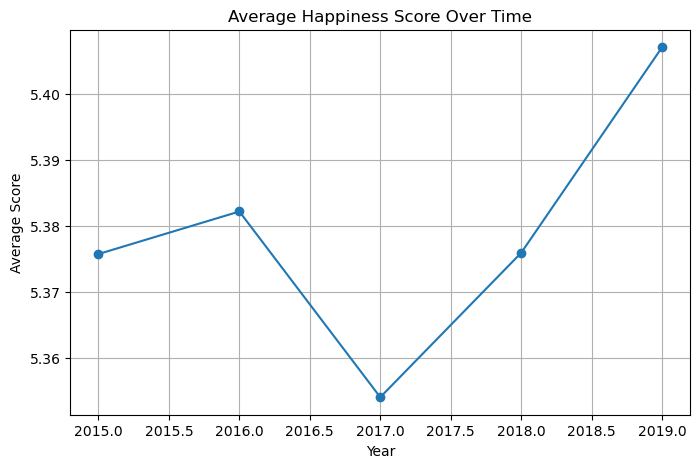

In [87]:
avg_score = df.groupby("Year")["Score"].mean()

print(avg_score)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
avg_score.plot(marker='o')
plt.title("Average Happiness Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.grid(True)
plt.show()

Is global freedom increasing over time ?


Year
2015    0.428615
2016    0.370994
2017    0.408786
2018    0.454506
2019    0.392571
Name: Freedom, dtype: float64


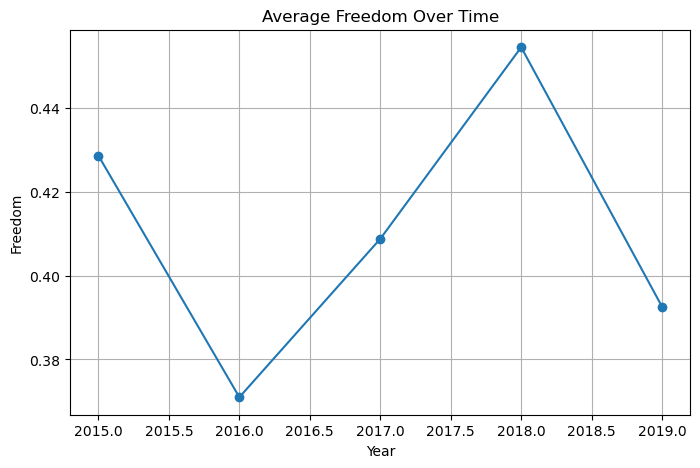

In [88]:
avg_freedom = df.groupby("Year")["Freedom"].mean()

print(avg_freedom)

plt.figure(figsize=(8,5))
avg_freedom.plot(marker='o')
plt.title("Average Freedom Over Time")
plt.xlabel("Year")
plt.ylabel("Freedom")
plt.grid(True)
plt.show()


Which countries moved the most in ranking over 5 years?


In [89]:
rank_change = df.pivot(index="Country", columns="Year", values="Rank")

rank_change["Rank Change"] = abs(rank_change[2019] - rank_change[2015])

print(rank_change["Rank Change"].sort_values(ascending=False).head(10))

Country
Venezuela      85.0
Zambia         53.0
Benin          53.0
Ivory Coast    52.0
Lesotho        47.0
Honduras       46.0
Hungary        42.0
Gabon          39.0
Romania        38.0
Cameroon       37.0
Name: Rank Change, dtype: float64



Which countries crossed from below-average to above-average happiness?


In [90]:
avg_score = df["Score"].mean()

pivot = df.pivot(index="Country", columns="Year", values="Score")

result = pivot[
    (pivot[2015] < avg_score) &
    (pivot[2019] > avg_score)
]

print(result)

Year                     2015   2016   2017   2018   2019
Country                                                  
Bosnia and Herzegovina  4.949  5.163  5.182  5.129  5.386
Dominican Republic      4.885  5.155  5.230  5.302  5.425
Honduras                4.788  4.871  5.181  5.504  5.860
Hungary                 4.800  5.145  5.324  5.620  5.758
Latvia                  5.098  5.560  5.850  5.933  5.940
Montenegro              5.192  5.161  5.237  5.347  5.523
Pakistan                5.194  5.132  5.269  5.472  5.653
Philippines             5.073  5.279  5.430  5.524  5.631
Portugal                5.102  5.123  5.195  5.410  5.693
Romania                 5.124  5.528  5.825  5.945  6.070
Serbia                  5.123  5.177  5.395  5.398  5.603
Tajikistan              4.786  4.996  5.041  5.199  5.467


Conclusion:

These countries improved from below the global average happiness score in 2015 to above the average by 2019.

If GDP doubles, does happiness necessarily increase?

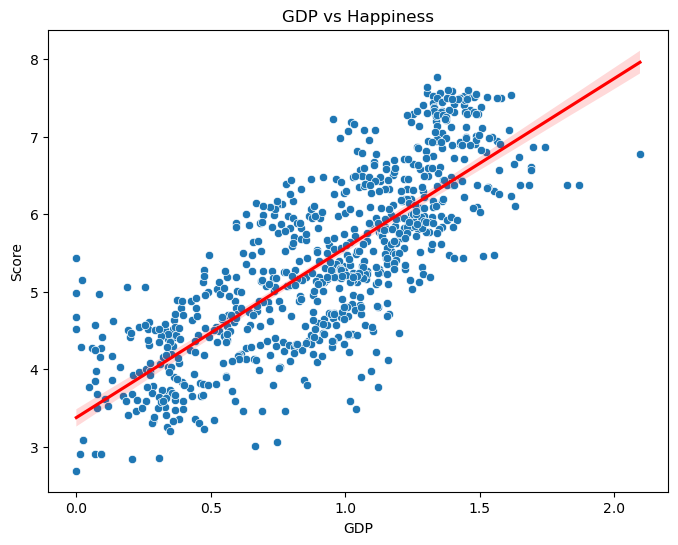

Correlation: 0.7892839967085098


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="GDP", y="Score")
sns.regplot(data=df, x="GDP", y="Score", scatter=False, color="red")

plt.title("GDP vs Happiness")
plt.show()

print("Correlation:", df["GDP"].corr(df["Score"]))

Conclusion:

Happiness generally increases with GDP, but the relationship is not perfectly linear. Higher GDP alone does not guarantee higher happiness.

Is there a threshold beyond which additional GDP has little effect on happiness?


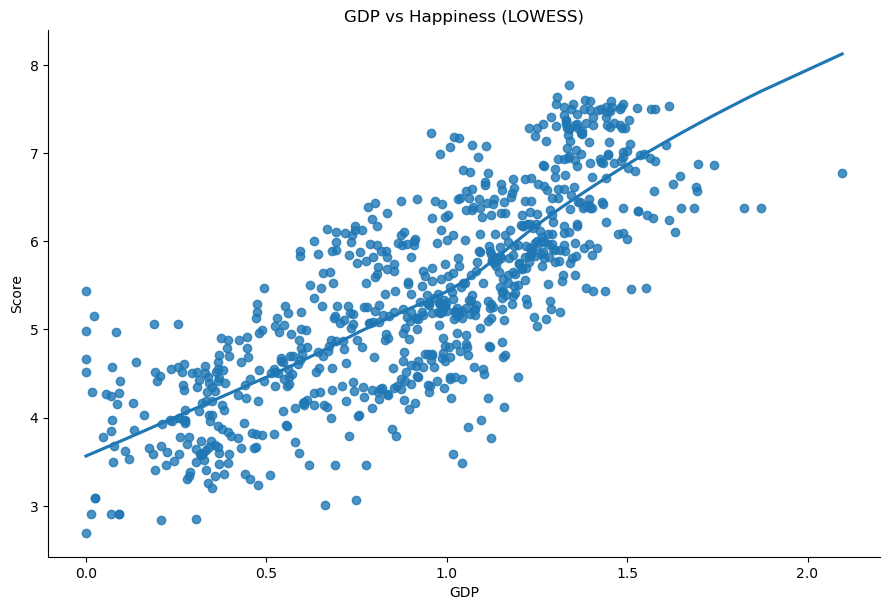

In [92]:
sns.lmplot(
    data=df,
    x="GDP",
    y="Score",
    lowess=True,
    height=6,
    aspect=1.5
)

plt.title("GDP vs Happiness (LOWESS)")
plt.show()

The curve suggests diminishing returns, where additional GDP has a smaller impact on happiness after a certain level.


Which factor appears to have the greatest influence on happiness across different years?


In [93]:
corr = df.groupby("Year").apply(
    lambda x: x.corr(numeric_only=True)["Score"]
)

print(corr)

Score   Freedom  Healthy Life Expectancy  Score       GDP  Year  Generosity  \
Year                                                                          
2015   0.568211                 0.724200    1.0  0.780966   NaN    0.180319   
2016   0.566827                 0.765384    1.0  0.790322   NaN    0.156848   
2017   0.570137                 0.781951    1.0  0.812469   NaN    0.155256   
2018   0.544280                 0.775814    1.0  0.802124   NaN    0.135825   
2019   0.566742                 0.779883    1.0  0.793883   NaN    0.075824   

Score  Social Support  Corruption      Rank  
Year                                         
2015         0.740605    0.395199 -0.992105  
2016         0.739252    0.402032 -0.995743  
2017         0.752737    0.429080 -0.992774  
2018         0.745760    0.405292 -0.991749  
2019         0.777058    0.385613 -0.989096  


C:\Users\sudha\AppData\Local\Temp\ipykernel_13672\3288470440.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr = df.groupby("Year").apply(


GDP, Social Support, Healthy Life Expectancy, and Freedom consistently show the strongest positive relationship with happiness.

Which countries consistently exceed expectations based on their economic indicators?


In [94]:
df["Expected"] = df["GDP"]

df["Difference"] = df["Score"] - df["Expected"]

print(
    df.groupby("Country")["Difference"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

Country
Finland        6.180840
Denmark        6.149271
Iceland        6.124477
Costa Rica     6.090545
Switzerland    6.039236
Norway         6.021619
New Zealand    5.995491
Netherlands    5.993587
Canada         5.962471
Sweden         5.915219
Name: Difference, dtype: float64


Are there countries that could serve as models for improving happiness despite limited economic resources?


In [95]:
model = df[
    (df["GDP"] < df["GDP"].mean()) &
    (df["Score"] > df["Score"].mean())
]

model[["Country","GDP","Score"]].drop_duplicates()

,Country,GDP,Score
41,El Salvador,0.764540,6.130
42,Guatemala,0.745530,6.123
43,Uzbekistan,0.632440,6.003
47,Ecuador,0.864020,5.975
50,Bolivia,0.681330,5.890
51,Moldova,0.594480,5.889
52,Paraguay,0.759850,5.878
56,Nicaragua,0.593250,5.828
57,Peru,0.900190,5.824
64,Jamaica,0.810380,5.709


If you were advising a government, which three indicators would you prioritize to improve national happiness, based on the data?

In [96]:
corr = df.corr(numeric_only=True)["Score"].sort_values(ascending=False)

print(corr)

Score                      1.000000
Difference                 0.955065
GDP                        0.789284
Expected                   0.789284
Healthy Life Expectancy    0.742456
Social Support             0.648799
Freedom                    0.551258
Corruption                 0.398418
Generosity                 0.137578
Year                       0.007065
Rank                      -0.992066
Name: Score, dtype: float64


Explain why for the above question?

These indicators consistently show strong positive correlations with happiness. Investing in healthcare, strengthening social support systems, and increasing personal freedom can improve citizens' quality of life and overall well-being.

Among countries with GDP above the global average, which have below-average happiness?


In [97]:
result = df[
    (df["GDP"] > df["GDP"].mean()) &
    (df["Score"] < df["Score"].mean())
]

result[["Country","GDP","Score","Year"]]

,Country,GDP,Score,Year
75,Turkey,1.06098,5.332,2015
79,Azerbaijan,1.02389,5.212,2015
82,Montenegro,0.97438,5.192,2015
85,Romania,1.04345,5.124,2015
86,Serbia,0.92053,5.123,2015
...,...,...,...,...
742,Iran,1.10000,4.548,2019
749,Tunisia,0.92100,4.461,2019
751,Iraq,1.04300,4.437,2019
755,Sri Lanka,0.94900,4.366,2019


These countries have strong economies but relatively low happiness, indicating that GDP alone is insufficient for improving well-being.

Which countries have high GDP but low social support?

In [98]:
result = df[
    (df["GDP"] > df["GDP"].mean()) &
    (df["Social Support"] < df["Social Support"].mean())
]

result[["Country","GDP","Social Support","Year"]]

,Country,GDP,Social Support,Year
13,Mexico,1.02054,0.91451,2015
23,Singapore,1.52186,1.02000,2015
37,Taiwan,1.29098,1.07617,2015
39,Suriname,0.99534,0.97200,2015
46,South Korea,1.24461,0.95774,2015
...,...,...,...,...
586,Iraq,1.01000,0.97100,2018
732,Albania,0.94700,0.84800,2019
742,Iran,1.10000,0.84200,2019
749,Tunisia,0.92100,1.00000,2019


Conclusion:

These countries are economically strong but have comparatively weaker social support systems, which may limit overall happiness.

Among countries with GDP below the global average, which have above-average happiness?


In [99]:
avg_gdp = df["GDP"].mean()
avg_score = df["Score"].mean()

result = df[
    (df["GDP"] < avg_gdp) &
    (df["Score"] > avg_score)
]

result[["Country","GDP","Score","Year"]].drop_duplicates()

,Country,GDP,Score,Year
41,El Salvador,0.764540,6.130,2015
42,Guatemala,0.745530,6.123,2015
43,Uzbekistan,0.632440,6.003,2015
47,Ecuador,0.864020,5.975,2015
50,Bolivia,0.681330,5.890,2015
51,Moldova,0.594480,5.889,2015
52,Paraguay,0.759850,5.878,2015
56,Nicaragua,0.593250,5.828,2015
57,Peru,0.900190,5.824,2015
64,Jamaica,0.810380,5.709,2015


Do countries with GDP in the top 25% always rank in the top 25% for happiness?


In [100]:
gdp_top = df["GDP"].quantile(0.75)
score_top = df["Score"].quantile(0.75)

result = df[df["GDP"] >= gdp_top]

result["Top_Happiness"] = result["Score"] >= score_top

print(result[["Country","GDP","Score","Top_Happiness"]])

             Country      GDP  Score  Top_Happiness
0        Switzerland  1.39651  7.587           True
1            Iceland  1.30232  7.561           True
2            Denmark  1.32548  7.527           True
3             Norway  1.45900  7.522           True
4             Canada  1.32629  7.427           True
..               ...      ...    ...            ...
679      South Korea  1.30100  5.895          False
680          Estonia  1.23700  5.893          False
683            Japan  1.32700  5.886          False
689  Northern Cyprus  1.26300  5.718          False
701        Hong Kong  1.43800  5.430          False

[196 rows x 4 columns]


C:\Users\sudha\AppData\Local\Temp\ipykernel_13672\4204825474.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result["Top_Happiness"] = result["Score"] >= score_top


Not all countries with top GDP are also in the top 25% for happiness, indicating that wealth alone does not guarantee happiness.

Which countries have GDP below the median but freedom above the median?


In [101]:
gdp_med = df["GDP"].median()
freedom_med = df["Freedom"].median()

result = df[
    (df["GDP"] < gdp_med) &
    (df["Freedom"] > freedom_med)
]

result[["Country","GDP","Freedom","Year"]]

,Country,GDP,Freedom,Year
11,Costa Rica,0.95578,0.63376,2015
15,Brazil,0.98124,0.49049,2015
32,Colombia,0.91861,0.53466,2015
33,Thailand,0.96690,0.55664,2015
42,Guatemala,0.74553,0.57733,2015
...,...,...,...,...
755,Sri Lanka,0.94900,0.47000,2019
756,Myanmar,0.71000,0.52500,2019
765,India,0.75500,0.49800,2019
775,Malawi,0.19100,0.44300,2019


Among high-GDP countries, which have the lowest generosity?


In [102]:
high = df[df["GDP"] > df["GDP"].mean()]

high.sort_values("Generosity").head(10)[
    ["Country","GDP","Generosity","Year"]
]

,Country,GDP,Generosity,Year
101,Greece,1.154060,0.000000,2015
707,Greece,1.181000,0.000000,2019
256,Greece,1.248860,0.000000,2016
401,Greece,1.289487,0.000000,2017
548,Greece,1.154000,0.000000,2018
63,Russia,1.137640,0.001990,2015
366,Lithuania,1.314582,0.010165,2017
217,Lithuania,1.269200,0.020250,2016
773,Botswana,1.041000,0.025000,2019
519,Lithuania,1.197000,0.026000,2018


Which countries have GDP above average but life expectancy below average?


In [103]:
result = df[
    (df["GDP"] > df["GDP"].mean()) &
    (df["Healthy Life Expectancy"] < df["Healthy Life Expectancy"].mean())
]

result[
    ["Country","GDP","Healthy Life Expectancy","Year"]
]

,Country,GDP,Healthy Life Expectancy,Year
39,Suriname,0.995340,0.608200,2015
69,Turkmenistan,0.958470,0.538860,2015
111,Iraq,0.985490,0.602370,2015
112,South Africa,0.920490,0.276880,2015
127,Botswana,0.993550,0.047760,2015
142,Gabon,1.060240,0.433720,2015
188,Colombia,1.030320,0.596590,2016
191,Saudi Arabia,1.489530,0.592670,2016
197,Suriname,1.096860,0.509330,2016
200,Trinidad and Tobago,1.325720,0.526080,2016


Compare happiness between countries with GDP above and below the median.


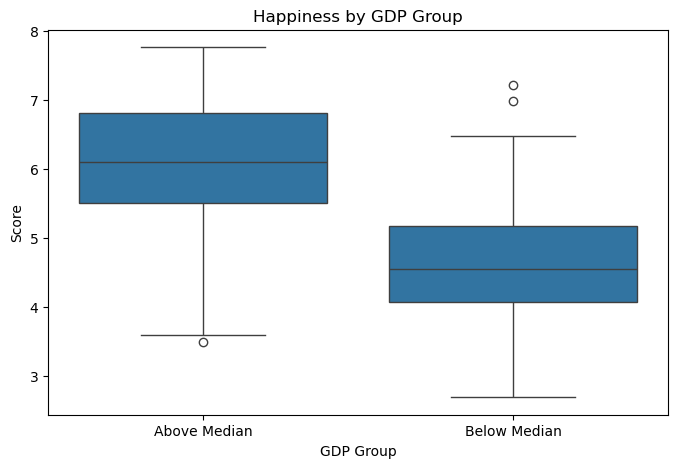

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

df["GDP Group"] = df["GDP"].apply(
    lambda x: "Above Median" if x >= df["GDP"].median() else "Below Median"
)

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="GDP Group",
            y="Score")

plt.title("Happiness by GDP Group")
plt.show()

Countries with GDP above the median generally show higher happiness scores than countries below the median.

Which countries improved happiness despite little or no GDP improvement?


In [105]:
gdp = df.pivot(index="Country", columns="Year", values="GDP")
score = df.pivot(index="Country", columns="Year", values="Score")

change = pd.DataFrame()

change["GDP Change"] = gdp[2019] - gdp[2015]
change["Score Change"] = score[2019] - score[2015]

result = change[
    (change["GDP Change"] <= 0.05) &
    (change["Score Change"] > 0)
]

print(result)

                     GDP Change  Score Change
Country                                      
Austria                 0.03877         0.046
Bahrain                 0.03824         0.239
Burundi                 0.03070         0.870
Chad                    0.00807         0.683
Comoros                 0.03494         0.017
Congo (Brazzaville)    -0.00566         0.823
Ecuador                 0.04798         0.053
El Salvador             0.02946         0.123
Finland                 0.04975         0.363
France                  0.04622         0.017
Gabon                  -0.00324         0.903
Germany                 0.04508         0.235
Greece                  0.02694         0.430
Honduras                0.04668         1.072
Italy                   0.04286         0.275
Jamaica                 0.02062         0.181
Lebanon                -0.03864         0.358
Luxembourg              0.04509         0.144
Norway                  0.02900         0.032
South Africa            0.03951   

Which countries have similar GDP but significantly different happiness scores?

In [106]:
temp = df.copy()

temp["GDP Bin"] = pd.cut(temp["GDP"], bins=10)

result = temp.groupby("GDP Bin")["Score"].agg(["min","max"])

print(result)

                   min    max
GDP Bin                      
(-0.0021, 0.21]  2.693  5.440
(0.21, 0.419]    2.853  5.057
(0.419, 0.629]   3.231  5.889
(0.629, 0.838]   3.006  6.436
(0.838, 1.048]   3.488  7.226
(1.048, 1.258]   3.766  7.286
(1.258, 1.467]   5.123  7.769
(1.467, 1.677]   5.458  7.554
(1.677, 1.886]   6.374  6.871
(1.886, 2.096]   6.774  6.774


C:\Users\sudha\AppData\Local\Temp\ipykernel_13672\1633218449.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = temp.groupby("GDP Bin")["Score"].agg(["min","max"])


Among the top 20 happiest countries, which have below-average GDP?


In [107]:
top20 = df.nsmallest(20, "Rank")

result = top20[top20["GDP"] < df["GDP"].mean()]

result[
    ["Country","Rank","GDP","Score","Year"]
]

,Country,Rank,GDP,Score,Year


Some of the happiest countries have GDP below the global average, showing that happiness depends on multiple factors beyond economic performance.

Which countries are in the bottom 20 for happiness despite above-average GDP?


In [108]:
avg_gdp = df["GDP"].mean()

bottom20 = df.nlargest(20, "Rank")

result = bottom20[bottom20["GDP"] > avg_gdp]

print(result[["Country","Rank","GDP","Score","Year"]])

Empty DataFrame
Columns: [Country, Rank, GDP, Score, Year]
Index: []


These countries have relatively strong economies but still rank among the least happy, suggesting that GDP alone does not determine happiness.

Among countries with happiness above 7, which have low generosity?


In [109]:
avg_generosity = df["Generosity"].mean()

result = df[
    (df["Score"] > 7) &
    (df["Generosity"] < avg_generosity)
]

print(result[["Country","Score","Generosity","Year"]])

        Country  Score  Generosity  Year
13       Mexico  7.187    0.140740  2015
326  Costa Rica  7.079    0.214613  2017
470     Finland  7.632    0.202000  2018
482  Costa Rica  7.072    0.143000  2018
626     Finland  7.769    0.153000  2019
637  Costa Rica  7.167    0.144000  2019
639  Luxembourg  7.090    0.194000  2019


Which countries consistently remain in the top happiness category across all years?


In [110]:
top = df[df["Rank"] <= 10]

print(top["Country"].value_counts())

Country
Switzerland    5
Iceland        5
Denmark        5
Norway         5
Canada         5
Finland        5
Netherlands    5
Sweden         5
New Zealand    5
Australia      4
Austria        1
Name: count, dtype: int64


Which countries moved from below-average happiness to above-average happiness over time?


In [111]:
avg_score = df["Score"].mean()

pivot = df.pivot(index="Country", columns="Year", values="Score")

result = pivot[
    (pivot[2015] < avg_score) &
    (pivot[2019] > avg_score)
]

print(result)

Year                     2015   2016   2017   2018   2019
Country                                                  
Bosnia and Herzegovina  4.949  5.163  5.182  5.129  5.386
Dominican Republic      4.885  5.155  5.230  5.302  5.425
Honduras                4.788  4.871  5.181  5.504  5.860
Hungary                 4.800  5.145  5.324  5.620  5.758
Latvia                  5.098  5.560  5.850  5.933  5.940
Montenegro              5.192  5.161  5.237  5.347  5.523
Pakistan                5.194  5.132  5.269  5.472  5.653
Philippines             5.073  5.279  5.430  5.524  5.631
Portugal                5.102  5.123  5.195  5.410  5.693
Romania                 5.124  5.528  5.825  5.945  6.070
Serbia                  5.123  5.177  5.395  5.398  5.603
Tajikistan              4.786  4.996  5.041  5.199  5.467



Which countries have high happiness despite below-average life expectancy?


In [112]:
avg_life = df["Healthy Life Expectancy"].mean()

result = df[
    (df["Score"] > avg_score) &
    (df["Healthy Life Expectancy"] < avg_life)
]

print(result[
    ["Country","Score","Healthy Life Expectancy","Year"]
])

                 Country  Score  Healthy Life Expectancy  Year
39              Suriname  6.269                 0.608200  2015
43            Uzbekistan  6.003                 0.597720  2015
50               Bolivia  5.890                 0.539200  2015
69          Turkmenistan  5.548                 0.538860  2015
188             Colombia  6.481                 0.596590  2016
191         Saudi Arabia  6.379                 0.592670  2016
196            Guatemala  6.324                 0.540390  2016
197             Suriname  6.269                 0.509330  2016
200  Trinidad and Tobago  6.168                 0.526080  2016
203          El Salvador  6.068                 0.596000  2016
206           Uzbekistan  5.987                 0.501630  2016
209               Belize  5.956                 0.455690  2016
211           Kazakhstan  5.919                 0.573860  2016
212              Moldova  5.897                 0.523090  2016
213               Russia  5.856                 0.58991

Which countries have moderate happiness despite high freedom?


In [113]:
avg_freedom = df["Freedom"].mean()

moderate = df["Score"].between(5,7)

result = df[
    (df["Freedom"] > avg_freedom) &
    moderate
]

print(result[
    ["Country","Freedom","Score","Year"]
])

                  Country  Freedom  Score  Year
15                 Brazil  0.49049  6.983  2015
16             Luxembourg  0.61583  6.946  2015
17                Ireland  0.61777  6.940  2015
18                Belgium  0.58450  6.937  2015
19   United Arab Emirates  0.64157  6.901  2015
..                    ...      ...    ...   ...
714               Morocco  0.41800  5.208  2019
717             Indonesia  0.49100  5.192  2019
718                 China  0.52100  5.191  2019
719               Vietnam  0.54300  5.175  2019
720                Bhutan  0.45700  5.082  2019

[262 rows x 4 columns]



Which countries with similar happiness have very different economic conditions?

In [114]:
temp = df.copy()

temp["Score Bin"] = pd.cut(temp["Score"], bins=10)

result = temp.groupby("Score Bin")["GDP"].agg(["min","max"])

print(result)

                    min       max
Score Bin                        
(2.688, 3.201]  0.00000  0.747190
(3.201, 3.708]  0.07600  1.041000
(3.708, 4.216]  0.04600  1.158510
(4.216, 4.723]  0.00000  1.198210
(4.723, 5.231]  0.00000  1.315175
(5.231, 5.739]  0.00000  1.551675
(5.739, 6.246]  0.59325  1.632952
(6.246, 6.754]  0.78100  1.870766
(6.754, 7.261]  0.95578  2.096000
(7.261, 7.769]  1.22857  1.616463


C:\Users\sudha\AppData\Local\Temp\ipykernel_13672\3715783531.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = temp.groupby("Score Bin")["GDP"].agg(["min","max"])


Which countries report low corruption 

In [115]:
avg_corr = df["Corruption"].mean()

result = df[df["Corruption"] > avg_corr]

print(result[
    ["Country","Corruption","Score","Year"]
].sort_values("Corruption", ascending=False))

          Country  Corruption  Score  Year
153        Rwanda     0.55191  3.465  2015
27          Qatar     0.52208  6.611  2015
309        Rwanda     0.50521  3.515  2016
23      Singapore     0.49210  6.798  2015
2         Denmark     0.48357  7.527  2015
..            ...         ...    ...   ...
502  Saudi Arabia     0.12700  6.371  2018
670     Nicaragua     0.12700  6.105  2019
197      Suriname     0.12692  6.269  2016
267    Bangladesh     0.12583  4.643  2016
108    Bangladesh     0.12569  4.694  2015

[273 rows x 4 columns]


These countries report relatively low perceived corruption and generally exhibit higher levels of trust in public institutions.


Which countries report high corruption yet maintain high happiness?


In [116]:
result = df[
    (df["Corruption"] < avg_corr) &
    (df["Score"] > avg_score)
]

print(result[
    ["Country","Corruption","Score","Year"]
])

                    Country  Corruption  Score  Year
10                   Israel     0.07785  7.278  2015
11               Costa Rica     0.10583  7.226  2015
22                Venezuela     0.11069  6.810  2015
24                   Panama     0.09270  6.786  2015
29                Argentina     0.08484  6.574  2015
..                      ...         ...    ...   ...
696                 Moldova     0.00000  5.529  2019
698              Montenegro     0.08000  5.523  2019
700                 Croatia     0.02200  5.432  2019
702      Dominican Republic     0.10100  5.425  2019
703  Bosnia and Herzegovina     0.00600  5.386  2019

[200 rows x 4 columns]


These countries maintain relatively high happiness despite higher perceived corruption, indicating that other factors such as social support, freedom, and health also contribute significantly to overall well-being.

Does corruption affect the Happiness of the country

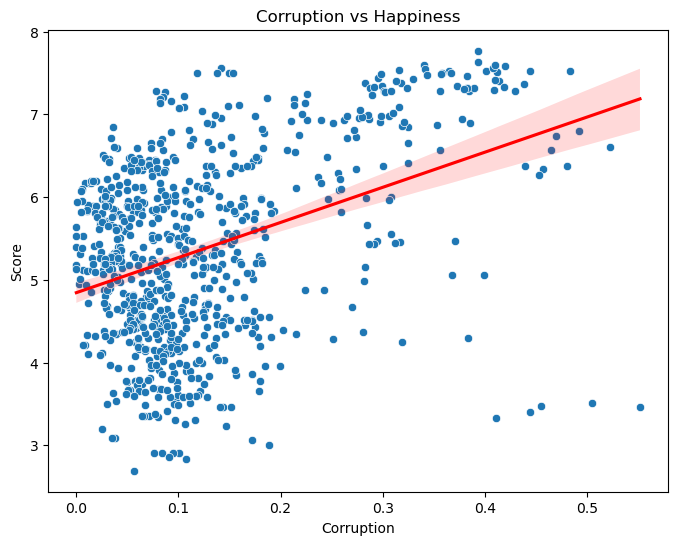

Correlation = 0.39841785694925136


In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Corruption", y="Score")
sns.regplot(data=df, x="Corruption", y="Score", scatter=False, color="red")

plt.title("Corruption vs Happiness")
plt.show()

print("Correlation =", df["Corruption"].corr(df["Score"]))

Compare GDP between low- and high-corruption countries.


Corruption Group
High Corruption    0.837699
Low Corruption     1.062126
Name: GDP, dtype: float64


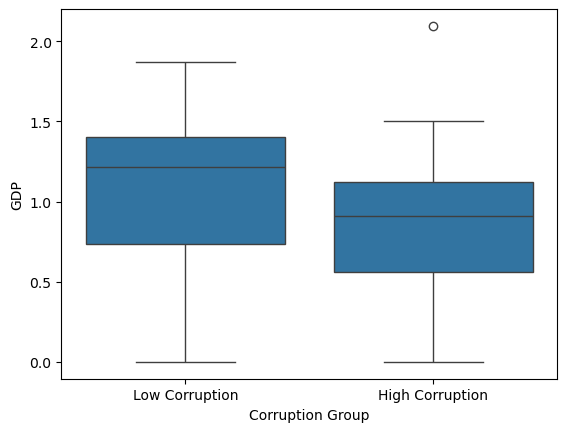

In [118]:
avg_corr = df["Corruption"].mean()

df["Corruption Group"] = df["Corruption"].apply(
    lambda x: "Low Corruption" if x >= avg_corr else "High Corruption"
)

print(df.groupby("Corruption Group")["GDP"].mean())

sns.boxplot(data=df, x="Corruption Group", y="GDP")
plt.show()


Which countries improved happiness despite increasing corruption?


In [120]:
score = df.pivot(index="Country",
                 columns="Year",
                 values="Score")

corr = df.pivot(index="Country",
                columns="Year",
                values="Corruption")

change = pd.DataFrame()

change["Score Change"] = score[2019]-score[2015]
change["Corruption Change"] = corr[2019]-corr[2015]

result = change[
    (change["Score Change"]>0) &
    (change["Corruption Change"]<0)
]

print(result)

                     Score Change  Corruption Change
Country                                             
Bahrain                     0.239           -0.19600
Bulgaria                    0.793           -0.00472
Burkina Faso                1.000           -0.01532
Cambodia                    0.881           -0.01047
Cameroon                    0.792           -0.02086
Comoros                     0.017           -0.12100
Congo (Brazzaville)         0.823           -0.02386
Cyprus                      0.357           -0.02046
Denmark                     0.073           -0.07357
Dominican Republic          0.540           -0.04134
Ecuador                     0.053           -0.09390
El Salvador                 0.123           -0.04376
Finland                     0.363           -0.02072
France                      0.017           -0.02346
Gabon                       0.903           -0.05591
Georgia                     0.222           -0.21931
Ghana                       0.363           -0

Which countries consistently maintain low corruption?


In [121]:
avg = df.groupby("Country")["Corruption"].mean()

print(avg.sort_values(ascending=False).head(15))

Country
Rwanda               0.473468
Singapore            0.467256
Denmark              0.429374
New Zealand          0.400015
Somaliland region    0.399280
Finland              0.398474
Sweden               0.397502
Switzerland          0.379763
Somaliland Region    0.367940
Qatar                0.355974
Norway               0.343951
Luxembourg           0.337421
Oman                 0.325240
Hong Kong            0.316427
Australia            0.314573
Name: Corruption, dtype: float64


Which countries have high corruption but excellent social support?


In [122]:
avg_corr = df["Corruption"].mean()
avg_social = df["Social Support"].mean()

result = df[
    (df["Corruption"]<avg_corr) &
    (df["Social Support"]>avg_social)
]

print(result[
    ["Country","Corruption","Social Support","Year"]
])

        Country  Corruption  Social Support  Year
10       Israel     0.07785         1.22393  2015
11   Costa Rica     0.10583         1.23788  2015
22    Venezuela     0.11069         1.25596  2015
24       Panama     0.09270         1.19850  2015
29    Argentina     0.08484         1.24823  2015
..          ...         ...             ...   ...
758     Ukraine     0.01000         1.39000  2019
769     Lesotho     0.09300         1.16900  2019
771    Zimbabwe     0.08900         1.11400  2019
773    Botswana     0.10000         1.14500  2019
776       Yemen     0.07700         1.16300  2019

[261 rows x 4 columns]


In [123]:
"""
Which countries have low corruption but low freedom?
"""



avg_corr = df["Corruption"].mean()
avg_freedom = df["Freedom"].mean()

result = df[
    (df["Corruption"]>avg_corr) &
    (df["Freedom"]<avg_freedom)
]

print(result[
    ["Country","Corruption","Freedom","Year"]
])


          Country  Corruption  Freedom  Year
34   Saudi Arabia     0.32524  0.31048  2015
58        Belarus     0.19090  0.37938  2015
67        Algeria     0.17383  0.28579  2015
75         Turkey     0.15746  0.22815  2015
79     Azerbaijan     0.16065  0.37030  2015
..            ...         ...      ...   ...
744       Georgia     0.16400  0.34600  2019
745        Gambia     0.16700  0.38200  2019
760     Swaziland     0.13500  0.31300  2019
770       Burundi     0.18000  0.22000  2019
774         Syria     0.14100  0.01300  2019

[64 rows x 4 columns]


Among low-corruption countries, which have the highest generosity?

In [124]:
result = df[
    df["Corruption"]>avg_corr
]

print(
    result.sort_values("Generosity",
                       ascending=False)[
        ["Country","Generosity","Corruption","Year"]
    ]
)

        Country  Generosity  Corruption  Year
428     Myanmar    0.838075    0.188816  2017
276     Myanmar    0.819710    0.202430  2016
128     Myanmar    0.795880    0.190340  2015
599     Myanmar    0.598000    0.178000  2018
341       Malta    0.574731    0.153066  2017
..          ...         ...         ...   ...
399  Azerbaijan    0.045269    0.180988  2017
744     Georgia    0.043000    0.164000  2019
597     Georgia    0.038000    0.215000  2018
715  Azerbaijan    0.035000    0.182000  2019
556  Azerbaijan    0.031000    0.176000  2018

[273 rows x 4 columns]


Which countries have high GDP + low happiness + high freedom?


In [125]:
avg_gdp = df["GDP"].mean()
avg_score = df["Score"].mean()
avg_freedom = df["Freedom"].mean()

result = df[
    (df["GDP"]>avg_gdp)&
    (df["Score"]<avg_score)&
    (df["Freedom"]>avg_freedom)
]

print(result[
    ["Country","GDP","Score","Freedom","Year"]
])

                Country       GDP  Score   Freedom  Year
87             Portugal  1.159910  5.102  0.514690  2015
127            Botswana  0.993550  4.332  0.494950  2015
240               China  1.027800  5.245  0.440120  2016
246  Dominican Republic  1.027870  5.155  0.522590  2016
251            Portugal  1.276070  5.123  0.447270  2016
270             Namibia  0.932870  4.574  0.486140  2016
273        South Africa  1.024160  4.459  0.424830  2016
274           Sri Lanka  0.973180  4.415  0.508170  2016
294            Botswana  1.094260  3.974  0.440890  2016
388              Jordan  0.991012  5.336  0.418421  2017
390             Jamaica  0.925579  5.311  0.474307  2017
393               China  1.081166  5.273  0.472788  2017
395           Indonesia  0.995539  5.262  0.443323  2017
400  Dominican Republic  1.079374  5.230  0.552590  2017
403            Portugal  1.315175  5.195  0.498465  2017
415        South Africa  1.054699  4.829  0.479247  2017
425             Namibia  0.9644

Which countries have low GDP + high happiness + high social support?


In [126]:
avg_social = df["Social Support"].mean()

result = df[
    (df["GDP"]<avg_gdp)&
    (df["Score"]>avg_score)&
    (df["Social Support"]>avg_social)
]

print(result[
    ["Country","GDP","Score","Social Support","Year"]
])

         Country       GDP  Score  Social Support  Year
43    Uzbekistan  0.632440  6.003        1.340430  2015
52      Paraguay  0.759850  5.878        1.304770  2015
56     Nicaragua  0.593250  5.828        1.141840  2015
64       Jamaica  0.810380  5.709        1.151020  2015
73     Indonesia  0.828270  5.399        1.087080  2015
206   Uzbekistan  0.735910  5.987        1.168100  2016
227     Paraguay  0.893730  5.538        1.111110  2016
343    Guatemala  0.872002  6.454        1.255585  2017
357    Nicaragua  0.737299  6.071        1.287216  2017
359  El Salvador  0.909784  6.003        1.182125  2017
361   Uzbekistan  0.786441  5.971        1.548969  2017
364       Belize  0.907975  5.956        1.081418  2017
370      Moldova  0.728871  5.838        1.251826  2017
372      Bolivia  0.833757  5.823        1.227619  2017
386  Philippines  0.857699  5.430        1.253918  2017
499    Guatemala  0.781000  6.382        1.268000  2018
509  El Salvador  0.806000  6.167        1.23100

Which countries have high life expectancy + low GDP + high happiness?


In [127]:
avg_life = df["Healthy Life Expectancy"].mean()
avg_gdp = df["GDP"].mean()
avg_score = df["Score"].mean()

result = df[
    (df["Healthy Life Expectancy"] > avg_life) &
    (df["GDP"] < avg_gdp) &
    (df["Score"] > avg_score)
]

print(result[["Country","Healthy Life Expectancy","GDP","Score","Year"]])

         Country  Healthy Life Expectancy       GDP  Score  Year
41   El Salvador                 0.677370  0.764540  6.130  2015
42     Guatemala                 0.644250  0.745530  6.123  2015
47       Ecuador                 0.790750  0.864020  5.975  2015
51       Moldova                 0.618260  0.594480  5.889  2015
52      Paraguay                 0.660980  0.759850  5.878  2015
56     Nicaragua                 0.743140  0.593250  5.828  2015
57          Peru                 0.730170  0.900190  5.824  2015
64       Jamaica                 0.687410  0.810380  5.709  2015
68        Kosovo                 0.631320  0.801480  5.589  2015
73     Indonesia                 0.637930  0.828270  5.399  2015
205    Nicaragua                 0.652130  0.693840  5.992  2016
357    Nicaragua                 0.653096  0.737299  6.071  2017
509  El Salvador                 0.639000  0.806000  6.167  2018
510    Nicaragua                 0.700000  0.668000  6.141  2018
517      Ecuador         

These countries achieve high happiness and long life expectancy despite having below-average GDP, indicating that health and social factors play an important role.

Which countries have high corruption + high happiness + high GDP?


In [128]:
avg_corr = df["Corruption"].mean()
avg_gdp = df["GDP"].mean()
avg_score = df["Score"].mean()

result = df[
    (df["Corruption"] < avg_corr) &
    (df["GDP"] > avg_gdp) &
    (df["Score"] > avg_score)
]

print(result[["Country","Corruption","GDP","Score","Year"]])

                    Country  Corruption      GDP  Score  Year
10                   Israel     0.07785  1.22857  7.278  2015
11               Costa Rica     0.10583  0.95578  7.226  2015
22                Venezuela     0.11069  1.04424  6.810  2015
24                   Panama     0.09270  1.06353  6.786  2015
29                Argentina     0.08484  1.05351  6.574  2015
..                      ...         ...      ...    ...   ...
695                  Serbia     0.03900  1.00400  5.603  2019
698              Montenegro     0.08000  1.05100  5.523  2019
700                 Croatia     0.02200  1.15500  5.432  2019
702      Dominican Republic     0.10100  1.01500  5.425  2019
703  Bosnia and Herzegovina     0.00600  0.94500  5.386  2019

[154 rows x 5 columns]


These countries maintain high happiness despite relatively higher perceived corruption, suggesting that GDP and other social factors also influence well-being.

Identify countries where Social Support increased but Happiness decreased over time.

In [129]:
social = df.pivot(index="Country", columns="Year", values="Social Support")
score = df.pivot(index="Country", columns="Year", values="Score")

change = pd.DataFrame()

change["Social Change"] = social[2019] - social[2015]
change["Score Change"] = score[2019] - score[2015]

result = change[
    (change["Social Change"] > 0) &
    (change["Score Change"] < 0)
]

print(result)

             Social Change  Score Change
Country                                 
Afghanistan        0.21415        -0.372
Albania            0.04366        -0.240
Algeria            0.08228        -0.394
Argentina          0.18377        -0.488
Australia          0.23877        -0.056
...                    ...           ...
Venezuela          0.17104        -2.103
Vietnam            0.43374        -0.185
Yemen              0.48207        -0.697
Zambia             0.14188        -1.022
Zimbabwe           0.08124        -0.947

[66 rows x 2 columns]


These countries experienced stronger social support over time, but their overall happiness declined, indicating that happiness depends on multiple interacting factors.

Compare countries that improved both GDP and Freedom with those that improved only one of these indicators.

In [130]:
gdp = df.pivot(index="Country", columns="Year", values="GDP")
freedom = df.pivot(index="Country", columns="Year", values="Freedom")

comparison = pd.DataFrame()

comparison["GDP Change"] = gdp[2019] - gdp[2015]
comparison["Freedom Change"] = freedom[2019] - freedom[2015]

comparison["Category"] = comparison.apply(
    lambda x:
        "Improved Both"
        if (x["GDP Change"] > 0 and x["Freedom Change"] > 0)
        else "Improved One or None",
    axis=1
)

print(comparison["Category"].value_counts())
print(comparison.head(20))

Category
Improved One or None    125
Improved Both            45
Name: count, dtype: int64
                        GDP Change  Freedom Change              Category
Country                                                                 
Afghanistan                0.03018        -0.23414  Improved One or None
Albania                    0.06833         0.02567         Improved Both
Algeria                    0.06271        -0.19979  Improved One or None
Angola                         NaN             NaN  Improved One or None
Argentina                  0.03849         0.02126         Improved Both
Armenia                    0.08179         0.08453         Improved Both
Australia                  0.03842        -0.09424  Improved One or None
Austria                    0.03877        -0.09233  Improved One or None
Azerbaijan                 0.01911        -0.01930  Improved One or None
Bahrain                    0.03824         0.08108         Improved Both
Bangladesh                 0.1644

Conclusion:

This comparison classifies countries based on whether they improved both GDP and freedom or improved only one (or neither), helping identify broader development patterns.

Overall Conclusion

• Happiness is influenced by multiple factors, including GDP, social support, healthy life expectancy, freedom, generosity, and corruption.
• GDP has a positive relationship with happiness, but wealth alone does not guarantee a happier population.
• Social support and healthy life expectancy consistently show strong associations with higher happiness.
• Freedom and low perceived corruption also contribute significantly to well-being.
• Several countries achieve high happiness despite below-average GDP, demonstrating the importance of social and institutional factors.
• Over the five-year period (2015–2019), happiness trends varied across countries and regions, reflecting differences in economic, social, and political conditions.